# Градиентный спуск

В этом домашнем задании вы напишете градиентный спуск для линейной регрессии, а так же посмотрите, как он ведёт себя с разными параметрами и разными функциями потерь.

Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек.  

In [1]:
import abc

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для обучения линейной регрессии необходим функционал ошибки, определим интерфейс для последующих реализаций.

In [2]:
class BaseLoss(abc.ABC):
    """Base class for losses"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """Calculate loss value based on inputs and weights

        Args:
            X: array with dataset objects, (n_samples, n_features)
            y: array with ground truth values, (n_samples,)
            w: linear regression weights, (n_features,)

        Returns:
            number, loss value
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """Calculate gradient vector based on inputs and weights

        Args:
            X: array with dataset objects, (n_samples, n_features)
            y: array with ground truth values, (n_samples,)
            w: linear regression weights, (n_features,)

        Returns:
            gradients for weights, (n_features,)
        """
        raise NotImplementedError

Вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — Mean Squared Error:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели, его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов

Для того чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        l = X.shape[0]
        errors = X @ w - y
        return np.linalg.norm(errors)**2 / l

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        return 2 * X.transpose() @ (X @ w - y) / len(X)

In [4]:
# Проведем небольшую проверку реализации

# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^t = w^{t-1} - \eta \nabla_{w} Q(w^{t-1}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> np.ndarray:
    """Weights optimization with gradient descent

    Args:
        w_init: initial weights, (n_features,)
        X: array with dataset objects, (n_samples, n_features)
        y: array with ground truth values, (n_samples,)
        loss: BaseLoss instance to calculate loss and gradients
        lr: learning rate, float
        n_iterations: number of iterations, int

    Returns:
        History of weights on each step, (n_iterations, n_features)
    """

    output = [w_init]
    w_prev = w_init
    for i in range(n_iterations):
        w_next = w_prev - lr * loss.calc_grad(X, y, w_prev)
        w_prev = w_next
        output.append(w_next)

    return np.array(output)
    

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории:

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045025
0.8670644395649494


In [8]:
def plot_gd(w_list: np.ndarray, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """Plot gradient descent trajectory

    Args:
        w_list: weights history, (n_iterations, n_features)
        X: array with dataset objects, (n_samples, n_features)
        y: array with ground truth values, (n_samples,)
        loss: BaseLoss instance to calculate loss and gradients
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.gca().set_aspect("equal")

    # visualize the level set
    CS = plt.contour(A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r)
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте не менее четырёх разных значений для `lr`. Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска

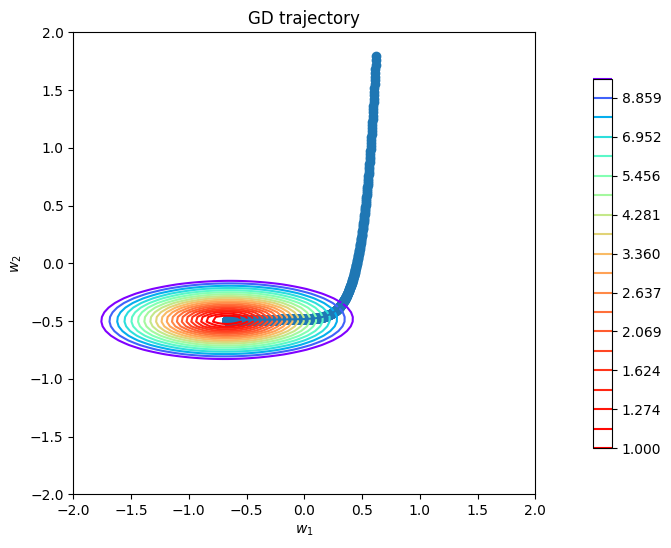

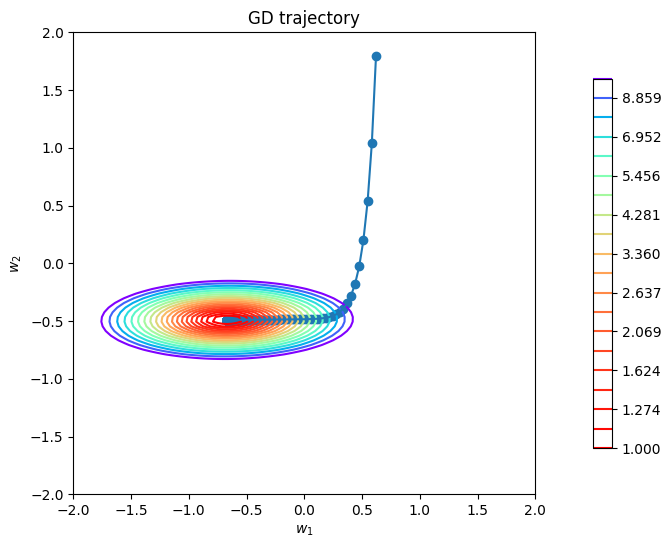

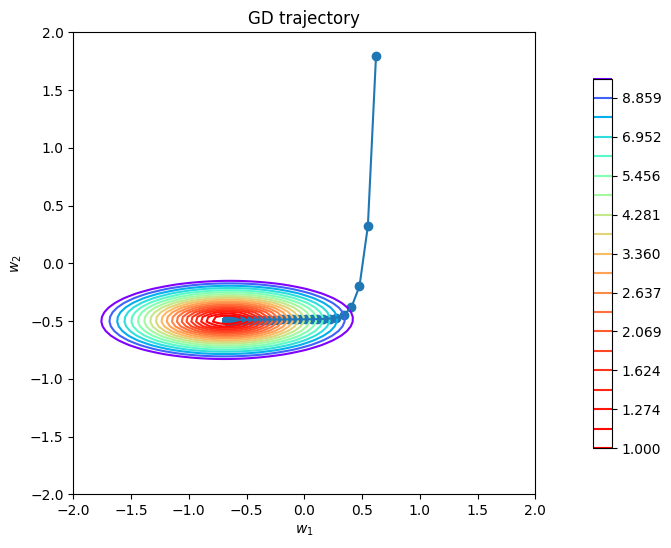

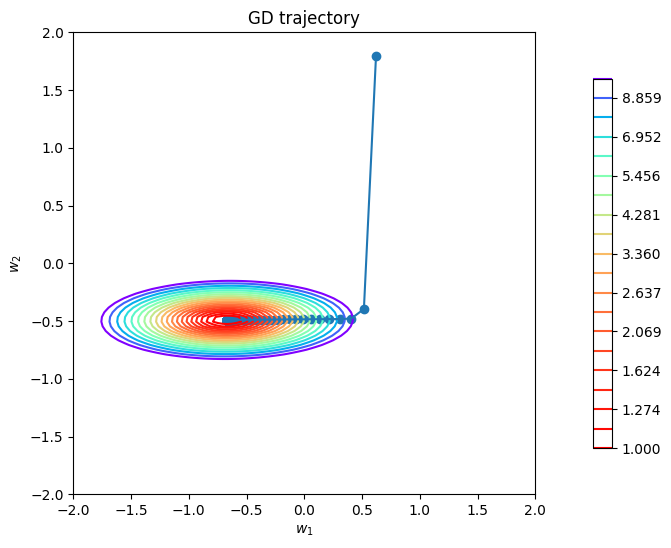

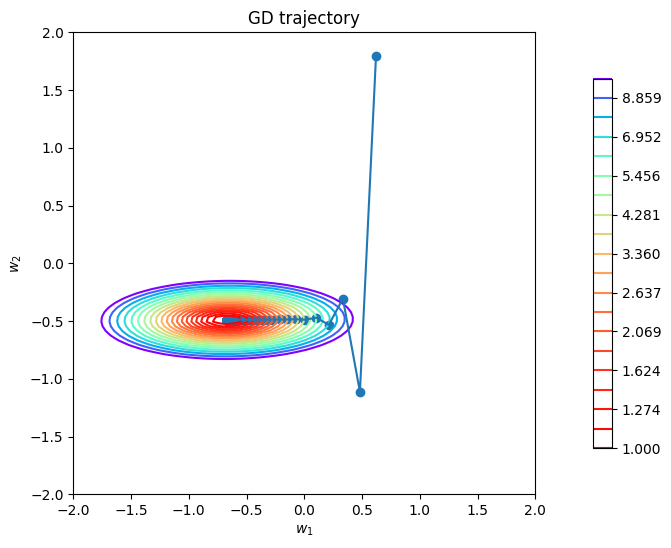

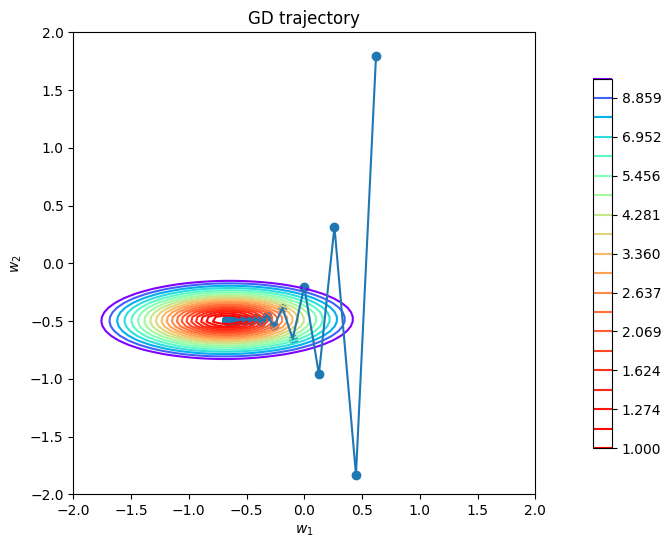

In [9]:
lrs = np.linspace(0.0001, 0.01, 6)
loss = MSELoss()
for lr in lrs:
    w_list = gradient_descent(w_init, X, y, loss, lr, 10000)
    plot_gd(w_list, X, y, loss)

*Learning rate влияет на скорость сходимости, а так же на конечную точность.*

Теперь реализуем стохастический градиентный спуск. Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> np.ndarray:
    """Weights optimization with stochastic gradient descent

    Args:
        w_init: initial weights, (n_features,)
        X: array with dataset objects, (n_samples, n_features)
        y: array with ground truth values, (n_samples,)
        loss: BaseLoss instance to calculate loss and gradients
        lr: learning rate, float
        batch_size: number of samples in each batch, int
        n_iterations: number of iterations, int

    Returns:
        History of weights on each step, (n_iterations, n_features)
    """
    
    batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
    X_batch = X[batch_indices]
    y_batch = y[batch_indices]

    output = [w_init]
    w_prev = w_init
    for i in range(n_iterations):
        w_next = w_prev - lr * loss.calc_grad(X_batch, y_batch, w_prev)
        w_prev = w_next
        output.append(w_next)

    return np.array(output)
    
    

При помощи функций `stochastic_gradient_descent` и `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

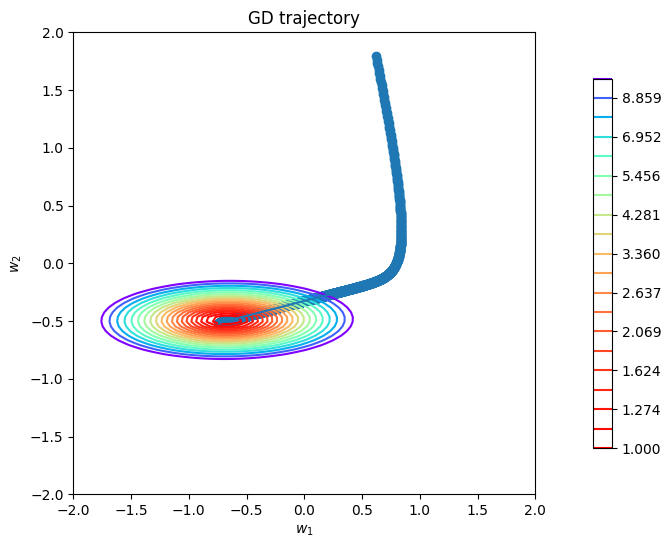

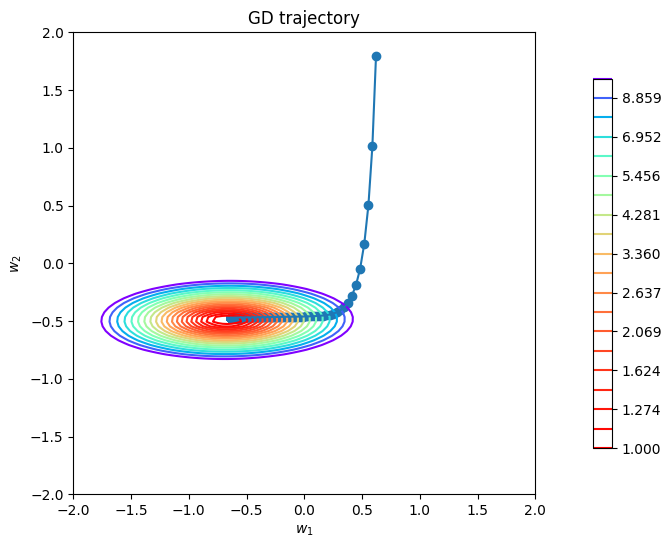

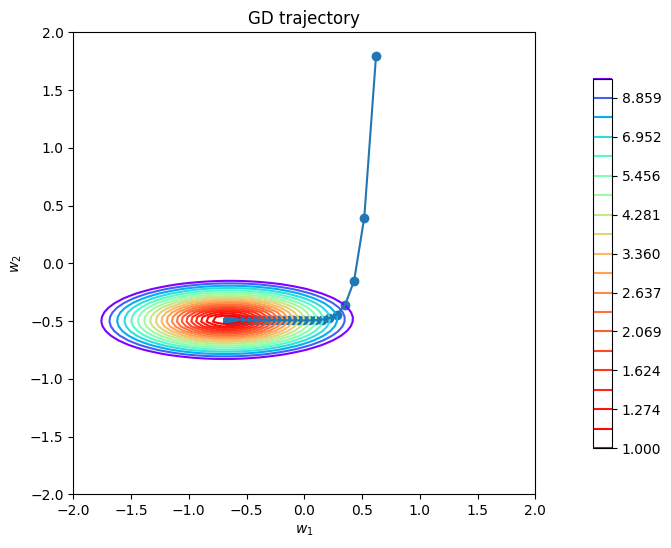

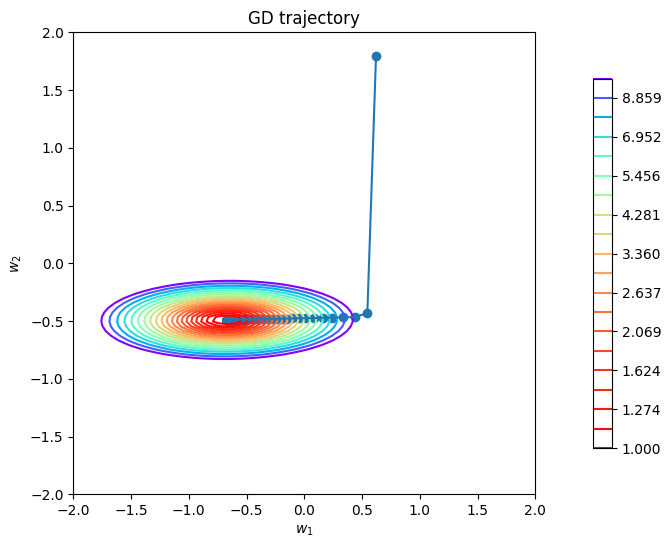

In [11]:
lrs = np.linspace(0.0001, 0.01, 6)
batch_sizes = [20, 50, 100, 150]
loss = MSELoss()
for lr, batch_size in zip(lrs, batch_sizes):
    w_list = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, 10000)
    plot_gd(w_list, X, y, loss)

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы более точнее этого минимума достичь и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

Реализуйте SGD на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [12]:
def stochastic_gradient_descent_with_decay(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> np.ndarray:
    """Weights optimization with SGD and learning rate decay

    Args:
        w_init: initial weights, (n_features,)
        X: array with dataset objects, (n_samples, n_features)
        y: array with ground truth values, (n_samples,)
        loss: BaseLoss instance to calculate loss and gradients
        lr: learning rate, float
        batch_size: number of samples in each batch, int
        p: learning rate decay factor, float
        n_iterations: number of iterations, int

    Returns:
        History of weights on each step, (n_iterations, n_features)
    """
    
    batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
    X_batch = X[batch_indices]
    y_batch = y[batch_indices]

    output = [w_init]
    w_prev = w_init
    for i in range(n_iterations):
        eta = lr * ((1 / (1 + i)) ** p)
        w_next = w_prev - eta * loss.calc_grad(X_batch, y_batch, w_prev)
        w_prev = w_next
        output.append(w_next)

    return np.array(output)

При помощи новой функции `stochastic_gradient_descent_with_decay` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска

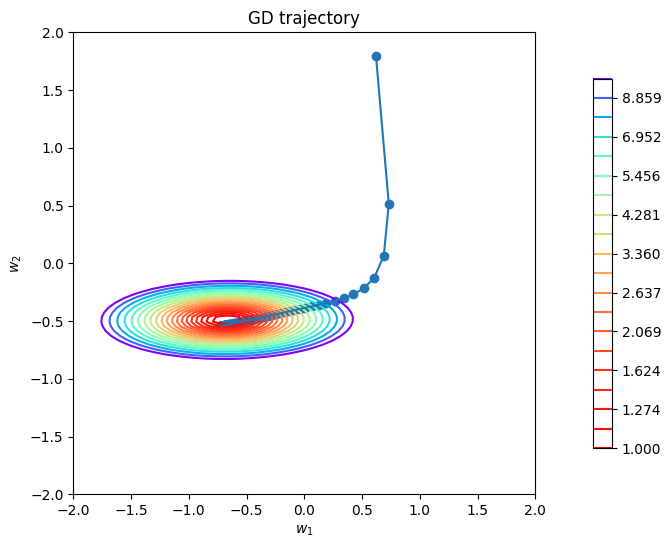

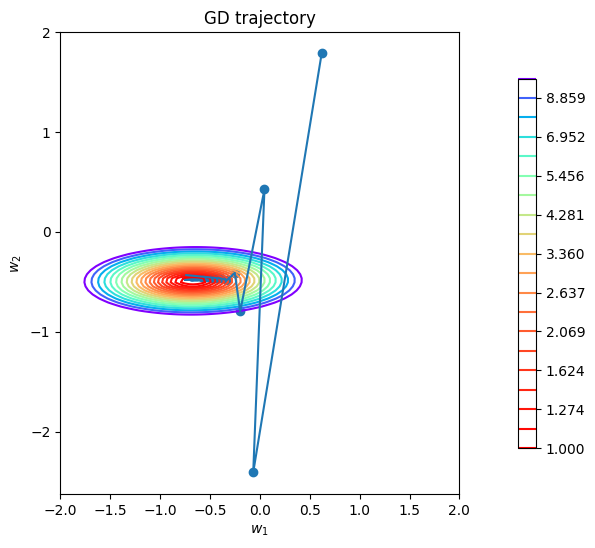

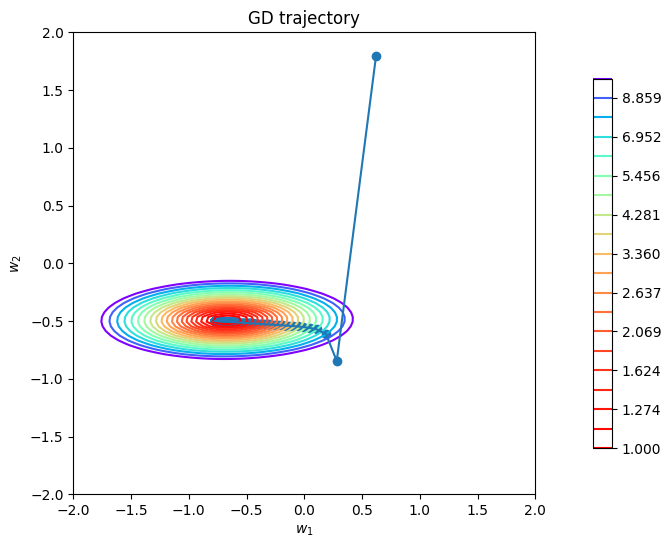

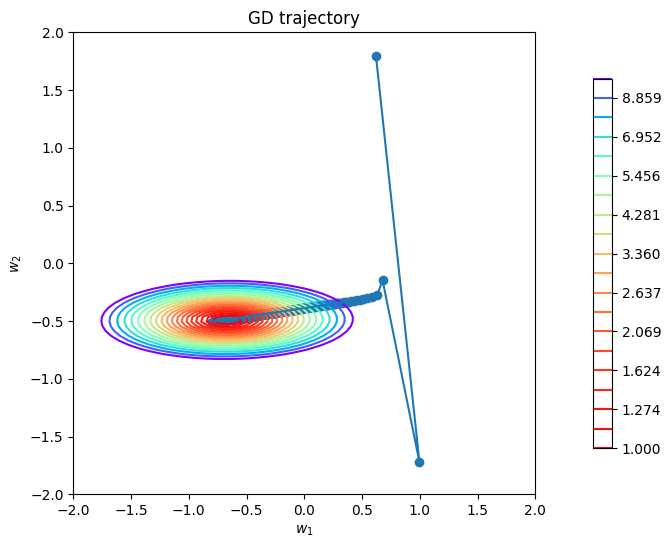

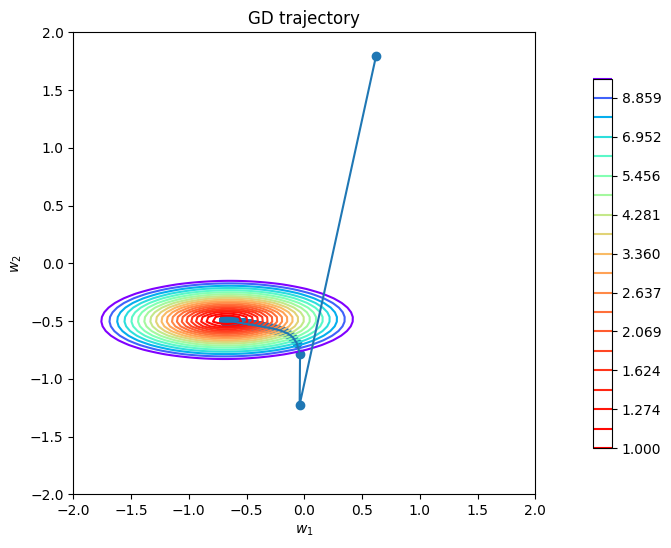

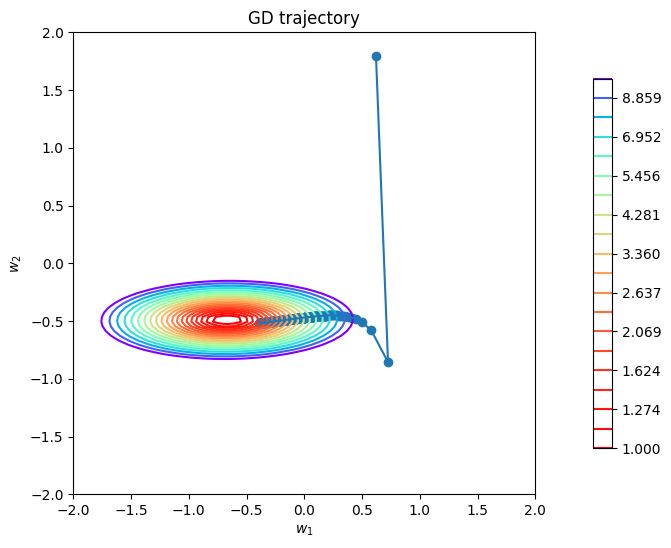

In [13]:
ps = np.linspace(0.1, 1, 6)
loss = MSELoss()
for p in ps:
    w_list = stochastic_gradient_descent_with_decay(w_init, X, y, loss, 0.01, 10, p, 10000)
    plot_gd(w_list, X, y, loss)

Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

*Преимущество SGD в том, что он быстрее сходится, чем GD, однако в конце концов его точность становится меньше чем точность GD.*

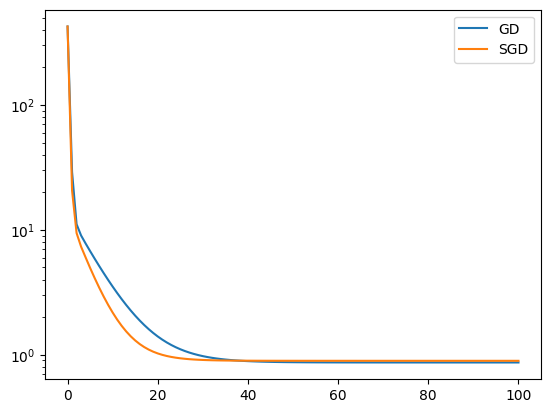

In [14]:
loss = MSELoss()
gd_w_list = gradient_descent(w_init, X, y, loss, 0.005, 100)
sgd_w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.005, 10, 100)

gd_losses = [loss.calc_loss(X, y, w) for w in gd_w_list]
sgd_losses = [loss.calc_loss(X, y, w) for w in sgd_w_list]

plt.plot(gd_losses, label="GD")
plt.plot(sgd_losses, label="SGD")

plt.yscale('log')
plt.legend()

plt.show()

## Часть 2. Линейная регрессия (5 баллов)

Напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`. Не забывайте про единичный признак!

В методе `predict` мы будем применять нашу регрессию к датасету,

In [15]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        ones_column = np.ones((X.shape[0], 1))
        X = np.hstack((ones_column, X))
        y = np.asarray(y)
        w_init = np.random.uniform(-2, 2, (X.shape[1]))
        
        self.w = gradient_descent(w_init, X, y, self.loss, 0.005)[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        ones_column = np.ones((X.shape[0], 1))
        X = np.hstack((ones_column, X))
        
        output = []
        for x in X:
            output.append(np.dot(x, self.w))
        return np.array(output)
        

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [16]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [17]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [18]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)
X_raw = X_raw.drop("index", axis=1)

Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [19]:
from sklearn.preprocessing import OneHotEncoder

numeric = X_raw.select_dtypes([np.number]).columns
categorial = list(X_raw.dtypes[X_raw.dtypes == "object"].index)

for col in numeric:
    X_mean = X_raw[col].mean()
    X_raw[col] = X_raw[col].fillna(X_mean)

for col in categorial:
    X_raw[col] = X_raw[col].fillna("NotGiven")

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_raw[categorial])

encoded_data = encoder.transform(X_raw[categorial])
encoded_feature_names = encoder.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_data, columns=encoded_feature_names)

X = X_raw.drop(columns=categorial)

X = pd.concat([X, encoded_df], axis=1)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train[numeric]) 

X_train[numeric] = scaler.transform(X_train[numeric])  
X_test[numeric] = scaler.transform(X_test[numeric])

Обучите линейную регрессию на обучающей выборке

In [21]:
loss = MSELoss()
model = LinearRegression(loss, 0.05)
model.fit(X_train, y_train)

Для оценки качества реализуем `r2_score`, который является нормализацией `mean_square_error`.

In [22]:
def r2(y_true: np.ndarray, y_predicted: np.ndarray) -> float:
    y_mean = np.mean(y_true)
    ss_tot = np.sum((y_true - y_mean)**2)
    ss_res = np.sum((y_true - y_predicted)**2)

    if ss_tot == 0:
        if ss_res == 0:
            return 1.0
        else:
            return np.nan

    r2 = 1 - (ss_res / ss_tot)
    return r2

Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке.

In [23]:
y_pred = model.predict(X_train)
train_score = r2(y_train, y_pred)
y_pred = model.predict(X_test)
test_score = r2(y_test, y_pred)

print(f"R2 on train: {train_score} // R2 on test: {test_score}")

R2 on train: 0.9693371612531272 // R2 on test: 0.9199556710225799


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

Обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак).

**Вопрос**: надо ли регуляризовывать bias?

**Ответ**: не нужно, т.к. bias не влияет на сложность модели а лишь на сдвиг.

Не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`

In [24]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        l = X.shape[0]
        errors = X @ w - y
        w_zero = np.copy(w)
        w_zero[0] = 0
        
        return np.linalg.norm(errors)**2 / l + self.coef * np.linalg.norm(w_zero)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        w_zero = np.copy(w)
        w_zero[0] = 0
        return 2 * X.transpose() @ (X @ w - y) / len(X) + 2 * self.coef * w_zero

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [25]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train[numeric]) 

X_train[numeric] = scaler.transform(X_train[numeric])
X_val[numeric] = scaler.transform(X_val[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

In [27]:
metrics = []
for l2 in np.linspace(0, 0.0005, 10):
    model = LinearRegression(MSEL2Loss(l2), 0.05)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    metrics.append((l2, r2(y_val, y_pred)))

metrics

[(np.float64(0.0), np.float64(0.9281396184807722)),
 (np.float64(5.555555555555556e-05), np.float64(0.9280588502462794)),
 (np.float64(0.00011111111111111112), np.float64(0.9279660017248896)),
 (np.float64(0.0001666666666666667), np.float64(0.9278589067274489)),
 (np.float64(0.00022222222222222223), np.float64(0.9277423764651324)),
 (np.float64(0.0002777777777777778), np.float64(0.9276148054923907)),
 (np.float64(0.0003333333333333334), np.float64(0.9274756574525401)),
 (np.float64(0.0003888888888888889), np.float64(0.9273283257984992)),
 (np.float64(0.00044444444444444447), np.float64(0.9271742586202086)),
 (np.float64(0.0005), np.float64(0.9270089453554832))]

In [28]:
X_train = np.vstack((X_train, X_val))
y_train = np.hstack((y_train, y_val))

In [29]:
reg_model = LinearRegression(MSEL2Loss(0.0005), 0.005)
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_train)
train_score = r2(y_train, y_pred)
y_pred = reg_model.predict(X_test)
test_score = r2(y_test, y_pred)

print(f"With L2-regularization: R2 on train: {train_score} // R2 on test: {test_score}")

model = LinearRegression(MSELoss(), 0.005)
model.fit(X_train, y_train)

y_pred = model.predict(X_train)
train_score = r2(y_train, y_pred)
y_pred = model.predict(X_test)
test_score = r2(y_test, y_pred)

print(f"Without regularization: R2 on train: {train_score} // R2 on test: {test_score}")

With L2-regularization: R2 on train: 0.9693065285204748 // R2 on test: 0.9051508541637802
Without regularization: R2 on train: 0.9697569133007546 // R2 on test: 0.8890365382169709


В нашем датасете могут быть выбросы, с ними хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

In [30]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        self.eps = eps

    def _phi_eps(self, z: float):
        eps = self.eps
        if np.abs(z) < eps:
            return 1/2 * z**2
        return eps * (np.abs(z) - (1/2 * eps))

    def _grad_phi_eps(self, z: float):
        eps = self.eps
        if np.abs(z) < eps:
            return z
        return eps * np.sign(z)

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        l = X.shape[0]
        predictions = X @ w
        errors = predictions - y

        return np.sum(self._phi_eps(z) for z in errors) / l

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        l = X.shape[0]
        predictions = X @ w
        errors = predictions - y
        grad_phi_values = np.array([self._grad_phi_eps(z) for z in errors])

        grad = (X.transpose() @ grad_phi_values) / l
        return grad
        

Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train[numeric]) 

X_train[numeric] = scaler.transform(X_train[numeric])
X_val[numeric] = scaler.transform(X_val[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

In [32]:
metrics = []
for eps in np.linspace(2000.0, 10000.0, 5):
    print(eps)
    model = LinearRegression(HuberLoss(eps), 0.05)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    metrics.append((eps, r2(y_val, y_pred)))

metrics

2000.0
4000.0
6000.0
8000.0
10000.0


[(np.float64(2000.0), np.float64(0.926733672630706)),
 (np.float64(4000.0), np.float64(0.9288985044392265)),
 (np.float64(6000.0), np.float64(0.9290011298516587)),
 (np.float64(8000.0), np.float64(0.9290072268259372)),
 (np.float64(10000.0), np.float64(0.9290061227176437))]

In [33]:
X_train = np.vstack((X_train, X_val))
y_train = np.hstack((y_train, y_val))

In [34]:
model = LinearRegression(MSELoss(), 0.005)
model.fit(X_train, y_train)

y_pred = model.predict(X_train)
train_score = r2(y_train, y_pred)
y_pred = model.predict(X_test)
test_score = r2(y_test, y_pred)

print(f"MSE without regularization model: R2 on train: {train_score} // R2 on test: {test_score}")


hub_model = LinearRegression(HuberLoss(8000), 0.005)
hub_model.fit(X_train, y_train)

y_pred = hub_model.predict(X_train)
train_score = r2(y_train, y_pred)
y_pred = hub_model.predict(X_test)
test_score = r2(y_test, y_pred)

print(f"Huber Loss model: R2 on train: {train_score} // R2 on test: {test_score}")

MSE without regularization model: R2 on train: 0.969756798478459 // R2 on test: 0.8890273749310593
Huber Loss model: R2 on train: 0.9690068854962841 // R2 on test: 0.9064101851908795


Вставьте ваш любимый мем 2025 в ячейку ниже: